In [1]:
import os, urllib, shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime 
from sklearn import metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

from sklearn import metrics
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')
# Ref: https://github.com/bnsreenu/python_for_microscopists/blob/master/198_Boruta_feature_selection_breast_cancer.py

In [2]:
data_dir = '/media/josh/wd/data/ML'
out_dir = '/media/josh/wd/data/ML'


In [3]:
dat_url = 'https://archive.ics.uci.edu/static/public/17/breast+cancer+wisconsin+diagnostic.zip'
file_name = os.path.basename(dat_url)
target_path = f'{data_dir}/{file_name}'

if not os.path.exists(f'{data_dir}/{file_name}'):
    urllib.request.urlretrieve(dat_url, target_path)
    shutil.unpack_archive(target_path, out_dir)
    

In [4]:
dat_url = 'https://raw.githubusercontent.com/dataspelunking/MLwR/master/Machine%20Learning%20with%20R%20(2nd%20Ed.)/Chapter%2003/wisc_bc_data.csv'
file_name = os.path.basename(dat_url)
target_path = f'{data_dir}/{file_name}'

if not os.path.exists(f'{data_dir}/{file_name}'):
    urllib.request.urlretrieve(dat_url, target_path)
#     shutil.unpack_archive(target_path, out_dir)

In [5]:
df = pd.read_csv(f'{data_dir}/wisc_bc_data.csv')

df.head(3)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
0,87139402,B,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.1242,0.09391,0.2827,0.06771
1,8910251,B,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.1916,0.07926,0.2940,0.07587
2,905520,B,11.04,16.83,70.92,373.2,0.10770,0.07804,0.03046,0.02480,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.1067,0.07431,0.2998,0.07881


In [6]:

####### Replace categorical values with numbers########
df['diagnosis'].value_counts()

#Define the dependent variable that needs to be predicted (labels)
y = df["diagnosis"].values

# Encoding categorical data
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
Y = labelencoder.fit_transform(y) # M=1 and B=0

In [7]:
#Define x and normalize values

#Define the independent variables. Let's also drop Gender, so we can normalize other data
X = df.drop(labels = ["diagnosis", "id"], axis=1) 

feature_names = np.array(X.columns)  #Convert dtype string?


scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

##Split data into train and test to verify accuracy after fitting the model. 

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)


In [20]:
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

# model = xgb.XGBClassifier()  #For Boruta

# define Boruta feature selection method
# feat_selector = BorutaPy(model, n_estimators='auto', verbose=2, random_state=1)
# feat_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=4242, max_iter = 50, perc = 90)
feat_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=4242)
# find all relevant features
feat_selector.fit(X_train, y_train)


# # check selected features
# print(feat_selector.support_)  #Should we accept the feature

# # check ranking of features
# print(feat_selector.ranking_) #Rank 1 is the best
# call transform() on X to filter it down to selected features
X_filtered = feat_selector.transform(X_train)  #Apply feature selection and return transformed data
# X_filtered.shape

# zip feature names, ranks, and decisions 
feature_ranks = list(zip(feature_names, 
                         feat_selector.ranking_, 
                         feat_selector.support_))

# print the results
for feat in feature_ranks:
    if feat[2] == True:
        print('Feature: {:<30} Rank: {},  Keep: {}'.format(feat[0], feat[1], feat[2]))
    

[ True  True  True  True  True  True  True  True False False  True False
  True  True False  True  True  True False False  True  True  True  True
  True  True  True  True  True  True]
[1 1 1 1 1 1 1 1 2 3 1 2 1 1 5 1 1 1 3 3 1 1 1 1 1 1 1 1 1 1]
Feature: radius_mean                    Rank: 1,  Keep: True
Feature: texture_mean                   Rank: 1,  Keep: True
Feature: perimeter_mean                 Rank: 1,  Keep: True
Feature: area_mean                      Rank: 1,  Keep: True
Feature: smoothness_mean                Rank: 1,  Keep: True
Feature: compactness_mean               Rank: 1,  Keep: True
Feature: concavity_mean                 Rank: 1,  Keep: True
Feature: points_mean                    Rank: 1,  Keep: True
Feature: radius_se                      Rank: 1,  Keep: True
Feature: perimeter_se                   Rank: 1,  Keep: True
Feature: area_se                        Rank: 1,  Keep: True
Feature: compactness_se                 Rank: 1,  Keep: True
Feature: concavity_se 

Accuracy =  0.965034965034965


<Axes: >

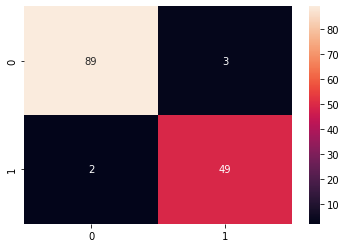

In [21]:

xgb_model = xgb.XGBClassifier()

xgb_model.fit(X_filtered, y_train)

#Now predict on test data using the trained model. 

#First apply feature selector transform to make sure same features are selected from test data
X_test_filtered = feat_selector.transform(X_test)
prediction_xgb = xgb_model.predict(X_test_filtered)


#Print overall accuracy

print ("Accuracy = ", metrics.accuracy_score(y_test, prediction_xgb))

#Confusion Matrix - verify accuracy of each class

cm = confusion_matrix(y_test, prediction_xgb)
#print(cm)
sns.heatmap(cm, annot=True)


In [22]:
# rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

model = xgb.XGBClassifier()  #For Boruta

# define Boruta feature selection method
# feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=1)
# feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=4242, max_iter = 50, perc = 90)
feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=4242)
# feat_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=4242, max_iter = 50, perc = 90)

# find all relevant features
feat_selector.fit(X_train, y_train)


# check selected features
print(feat_selector.support_)  #Should we accept the feature

# check ranking of features
print(feat_selector.ranking_) #Rank 1 is the best

# call transform() on X to filter it down to selected features
X_filtered = feat_selector.transform(X_train)  #Apply feature selection and return transformed data


# zip feature names, ranks, and decisions 
feature_ranks = list(zip(feature_names, 
                         feat_selector.ranking_, 
                         feat_selector.support_))

# print the results
# for feat in feature_ranks:
#     print('Feature: {:<30} Rank: {},  Keep: {}'.format(feat[0], feat[1], feat[2]))
    
for feat in feature_ranks:
    if feat[2] == True:
        print('Feature: {:<30} Rank: {},  Keep: {}'.format(feat[0], feat[1], feat[2]))


[ True  True False False False False False  True False False False False
 False False False False False False False False  True  True  True  True
 False False  True  True False False]
[ 1  1 20  2  8 15  3  1 15 20  4 10  2  6 18 12 18  7 17  4  1  1  1  1
  9 14  1  1 12 12]
Feature: radius_mean                    Rank: 1,  Keep: True
Feature: texture_mean                   Rank: 1,  Keep: True
Feature: points_mean                    Rank: 1,  Keep: True
Feature: radius_worst                   Rank: 1,  Keep: True
Feature: texture_worst                  Rank: 1,  Keep: True
Feature: perimeter_worst                Rank: 1,  Keep: True
Feature: area_worst                     Rank: 1,  Keep: True
Feature: concavity_worst                Rank: 1,  Keep: True
Feature: points_worst                   Rank: 1,  Keep: True


Accuracy =  0.9790209790209791


<Axes: >

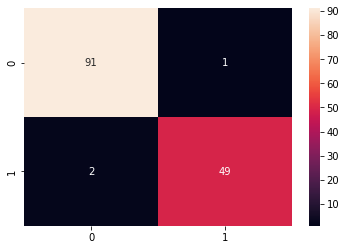

In [16]:

xgb_model = xgb.XGBClassifier()

xgb_model.fit(X_filtered, y_train)

#Now predict on test data using the trained model. 

#First apply feature selector transform to make sure same features are selected from test data
X_test_filtered = feat_selector.transform(X_test)
prediction_xgb = xgb_model.predict(X_test_filtered)


#Print overall accuracy

print ("Accuracy = ", metrics.accuracy_score(y_test, prediction_xgb))

#Confusion Matrix - verify accuracy of each class

cm = confusion_matrix(y_test, prediction_xgb)
#print(cm)
sns.heatmap(cm, annot=True)